In [13]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()
from fastbook import *

Extracting the data

In [14]:
def get_data(url, presize, resize):
    path = untar_data(url)   #loading the path for the extraction of data
    return DataBlock(
        blocks = (ImageBlock, CategoryBlock),  #the training data is an image block and the output is category block
        get_items = get_image_files,
        splitter = GrandparentSplitter(valid_name = 'val'),  #splitting the data based on validation dataset
        get_y = parent_label,
        item_tfms = Resize(presize),   #resizing the training images to the size of presize * presize
        batch_tfms = [*aug_transforms(min_scale=0.5, size=resize),   #applying data augmentation to images
                    Normalize.from_stats(*imagenet_stats)]
    ).dataloaders(path,bs = 128)

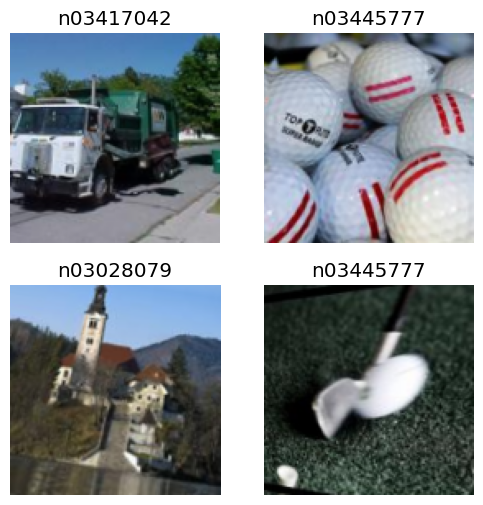

In [15]:
dls = get_data(URLs.IMAGENETTE_160, 160, 128)
dls.show_batch(max_n = 4)

CNN architecture where we use the average of activation neurons of all the channels, inorder to find the one final output


In [16]:
def block(ni, nf):  #here ni is the number of input channels and nf is the number of features or kernels
    return ConvLayer(ni,nf,stride = 2)
def get_model():
    return nn.Sequential(
        block(3,16),
        block(16,32),
        block(32,64),
        block(64,128),
        block(128,256),
        nn.AdaptiveAvgPool2d(1),  #applying average to activation neurons of all the feature maps
        Flatten(),
        nn.Linear(256, dls.c)
    )
    

In [17]:
learn = Learner(dls, get_model(), loss_func = nn.CrossEntropyLoss(),metrics = accuracy).to_fp16()


Finding the optimal learning rate

<div></div>

SuggestedLRs(valley=0.0006918309954926372)

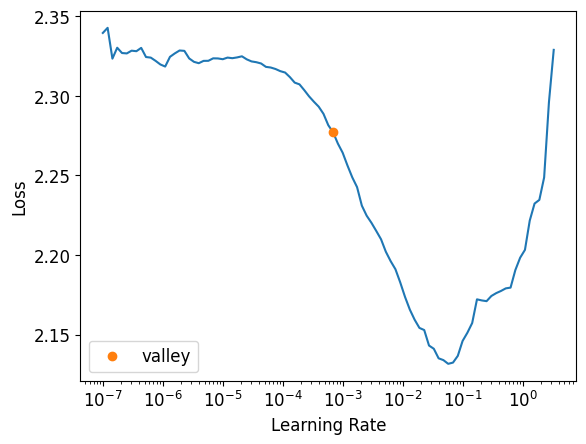

In [18]:
learn.lr_find()

As we can see from the above result that the optimal learning rate here is: 0.057

Training the model

In [19]:
learn.fit_one_cycle(5, 0.0398)

epoch,train_loss,valid_loss,accuracy,time
0,1.834004,8.116462,0.160255,00:08
1,1.560891,1.562586,0.513121,00:08
2,1.307579,1.267643,0.602038,00:08
3,1.105589,1.241519,0.611465,00:08
4,0.969613,0.941726,0.694268,00:08


Residual block

In [20]:
class ResBlock(Module):
    def __init__(self,ni,nf):
        self.convs = nn.Sequential(
            ConvLayer(ni,nf),  #ni represents the number of input channels and nf represents the number of features
            ConvLayer(nf,nf,norm_type = NormType.BatchZero)  #as this second layer's input must match with the output of the first layer, we are using (nf,nf) here.
        )
    def forward(self,x):
        return x + self.convs(x)
        

Creating a block having identity function 

In [21]:
def conv_block(ni,nf,stride):
    return nn.Sequential(
        ConvLayer(ni,nf,stride = stride),
        ConvLayer(nf,nf,act_cls = None, norm_type = NormType.BatchZero)  
    )
    

Complete residual block


In [22]:
class ResBlock(Module):
    def __init__(self,ni,nf,stride = 1):
        self.convs = conv_block(ni,nf,stride)  #this is our layer which predicts the residual part
        #if the number of input channels match with the number of filters then F(X) will be X automatically, no need for using kernel of size 1*1
        #our identity function mapping is here 
        self.identityconv = noop if ni == nf else ConvLayer(ni,nf,1,act_cls = None)   #if the number of input channels doesnot match with the number of filters then we use kernel of size 1*1 , to make the number of channels produced by identity function match with the number of output feature map of the convolutional layer
        self.pool = noop if stride == 1 else nn.AvgPool2d(2,ceil_mode = True)  #if the passed stride is not 1 then obviously in most cases the stride will be 2,and we are using average pooling to reduce the size of output feature map by half, as using stride = 2 reduces the dimension of output into half
        #thats why we are using average pooling to make the output of required shape
    def forward(self,x):
        return F.relu(self.convs(x) + self.identityconv(self.pool(x)))  #then we finalize the actual flow of resnet
        

In [24]:
def block(ni,nf):
    return ResBlock(ni,nf,stride = 2)
learn = Learner(dls, get_model(), loss_func = nn.CrossEntropyLoss(),metrics = accuracy).to_fp16()


Finding the optimal learning rate

<div></div>

SuggestedLRs(valley=0.00363078061491251)

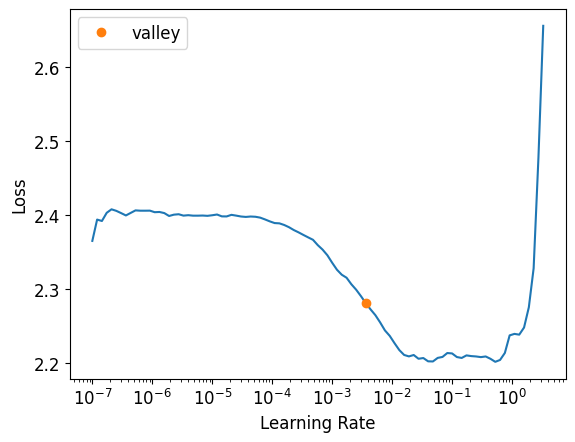

In [25]:
learn.lr_find()

Training the model with the complete residual block

In [27]:
learn.fit_one_cycle(8, 0.0036)

epoch,train_loss,valid_loss,accuracy,time
0,0.957400,1.035841,0.675414,00:09
1,1.009143,1.519577,0.537834,00:09
2,0.957516,1.080304,0.652739,00:09
3,0.884923,0.949807,0.700382,00:09
4,0.800016,0.876441,0.717197,00:09
5,0.703761,0.791495,0.752102,00:09
6,0.631948,0.698804,0.772739,00:09
7,0.597131,0.666179,0.784459,00:09
